In [1]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:

SEED = 42
DATASET_FILE = "creditcard.csv"

print("Settings configured successfully!")

Settings configured successfully!


In [3]:


print("Current working directory:")
print(os.getcwd())

print("\nFiles in current directory:")
print(os.listdir())

if os.path.exists(DATASET_FILE):
    print("\ncreditcard.csv found successfully!")
else:
    print("\nERROR: creditcard.csv not found.")
    print("Place creditcard.csv in the current folder.")

Current working directory:
C:\Users\Santanu Mondal\Downloads\files\jupytertest

Files in current directory:
['.ipynb_checkpoints', '02_fraud_detection.ipynb', 'creditcard.csv', 'eda_overview.png', 'generate_sample_data.ipynb', 'model_evaluation.png']

creditcard.csv found successfully!


In [4]:


df = pd.read_csv(DATASET_FILE)

print("Dataset loaded successfully!")

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
display(df.head())

Dataset loaded successfully!

Dataset Shape:
(5000, 31)

First 5 Rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,82802.628454,-0.541007,-0.583123,0.437018,-1.369133,-0.564310,0.684361,0.016415,0.501471,0.336367,...,0.418194,1.044784,0.040108,0.202268,-0.895405,0.397246,-0.335082,1.039046,72.145426,0.0
1,12402.859316,0.019600,0.596081,0.394820,1.469213,0.102883,-0.601788,0.959174,2.158886,-1.401292,...,0.676872,-0.196908,-0.012649,0.076124,1.883004,-2.067351,0.772574,0.470844,64.083782,0.0
2,9046.947488,1.328166,0.867394,-0.580164,1.430624,0.195366,-0.704315,0.611995,0.412981,0.167513,...,-0.356175,0.519396,-0.213854,1.076086,2.306483,0.082563,-0.944848,-1.443422,126.760802,0.0
3,60603.001710,3.112910,-0.705317,1.312208,0.378354,0.967779,-0.501367,-0.821389,0.616501,-0.612904,...,0.790421,0.429239,1.597988,-1.795097,-0.876482,-0.262036,0.607088,-1.730730,2.804574,0.0
4,171065.128157,-0.034551,-0.028817,-0.921718,-1.442854,-1.225308,-0.912963,2.861139,-0.416484,-0.490050,...,0.313216,-0.521431,0.228576,0.101066,1.356683,-0.344029,-0.019738,0.237951,15.709471,0.0


In [5]:

print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nClass Distribution:")
print(df["Class"].value_counts())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    5000 non-null   float64
 1   V1      5000 non-null   float64
 2   V2      5000 non-null   float64
 3   V3      5000 non-null   float64
 4   V4      5000 non-null   float64
 5   V5      5000 non-null   float64
 6   V6      5000 non-null   float64
 7   V7      5000 non-null   float64
 8   V8      5000 non-null   float64
 9   V9      5000 non-null   float64
 10  V10     5000 non-null   float64
 11  V11     5000 non-null   float64
 12  V12     5000 non-null   float64
 13  V13     5000 non-null   float64
 14  V14     5000 non-null   float64
 15  V15     5000 non-null   float64
 16  V16     5000 non-null   float64
 17  V17     5000 non-null   float64
 18  V18     5000 non-null   float64
 19  V19     5000 non-null   float64
 20  V20     5000 non-null   float64
 21  V21     5000 non

In [6]:


fraud_percent = df["Class"].mean() * 100

print(
    f"Fraud transactions are only "
    f"{fraud_percent:.3f}% of the dataset."
)

print("\nThis is a highly imbalanced classification problem.")

Fraud transactions are only 1.700% of the dataset.

This is a highly imbalanced classification problem.


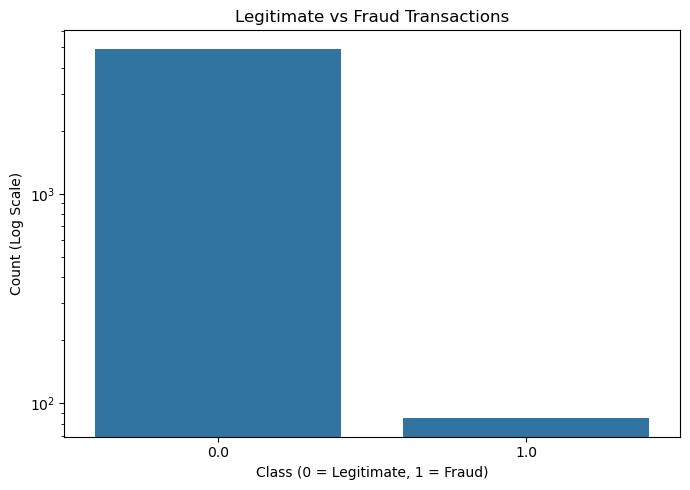

In [7]:


plt.figure(figsize=(7, 5))

sns.countplot(
    x="Class",
    data=df
)

plt.yscale("log")

plt.title("Legitimate vs Fraud Transactions")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Count (Log Scale)")

plt.tight_layout()

plt.show()

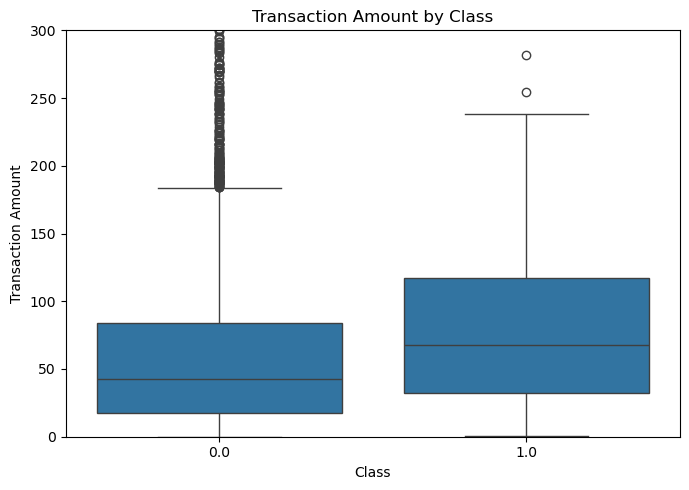

In [8]:


plt.figure(figsize=(7, 5))

sns.boxplot(
    x="Class",
    y="Amount",
    data=df
)

plt.ylim(0, 300)

plt.title("Transaction Amount by Class")
plt.xlabel("Class")
plt.ylabel("Transaction Amount")

plt.tight_layout()

plt.show()

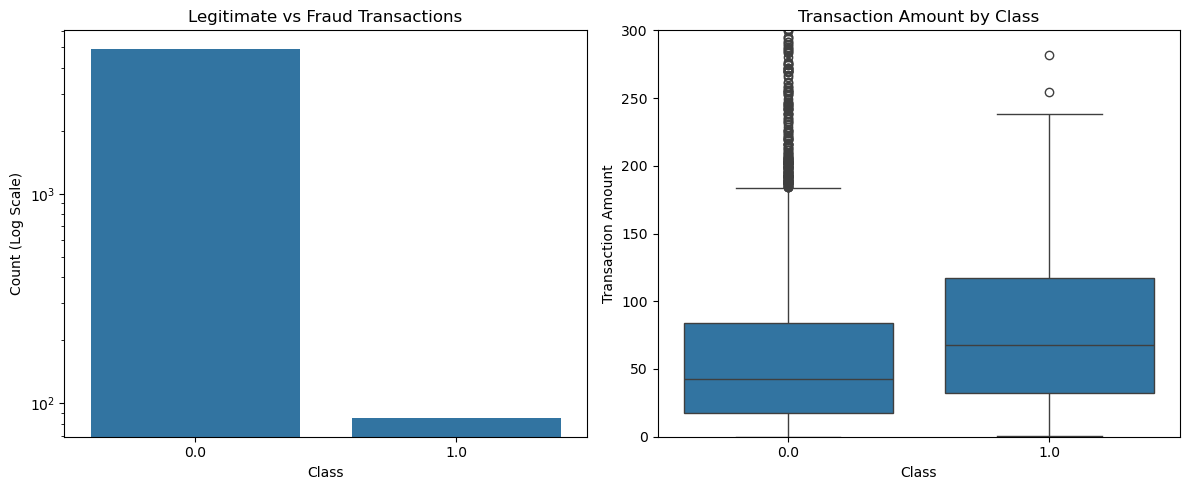

Saved: eda_overview.png


In [9]:

plt.figure(figsize=(12, 5))

# Class distribution
plt.subplot(1, 2, 1)

sns.countplot(
    x="Class",
    data=df
)

plt.yscale("log")

plt.title("Legitimate vs Fraud Transactions")
plt.xlabel("Class")
plt.ylabel("Count (Log Scale)")


# Transaction amount
plt.subplot(1, 2, 2)

sns.boxplot(
    x="Class",
    y="Amount",
    data=df
)

plt.ylim(0, 300)

plt.title("Transaction Amount by Class")
plt.xlabel("Class")
plt.ylabel("Transaction Amount")

plt.tight_layout()

plt.savefig(
    "eda_overview.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: eda_overview.png")

In [10]:

scaler = StandardScaler()

df["scaled_amount"] = scaler.fit_transform(
    df["Amount"].values.reshape(-1, 1)
)

df["scaled_time"] = scaler.fit_transform(
    df["Time"].values.reshape(-1, 1)
)

df.drop(
    ["Time", "Amount"],
    axis=1,
    inplace=True
)

print("Time and Amount scaled successfully!")

print("\nUpdated Dataset:")
display(df.head())

Time and Amount scaled successfully!

Updated Dataset:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
0,-0.541007,-0.583123,0.437018,-1.369133,-0.564310,0.684361,0.016415,0.501471,0.336367,-0.700974,...,1.044784,0.040108,0.202268,-0.895405,0.397246,-0.335082,1.039046,0.0,0.184320,-0.060946
1,0.019600,0.596081,0.394820,1.469213,0.102883,-0.601788,0.959174,2.158886,-1.401292,-0.100019,...,-0.196908,-0.012649,0.076124,1.883004,-2.067351,0.772574,0.470844,0.0,0.054267,-1.467712
2,1.328166,0.867394,-0.580164,1.430624,0.195366,-0.704315,0.611995,0.412981,0.167513,-0.945966,...,0.519396,-0.213854,1.076086,2.306483,0.082563,-0.944848,-1.443422,0.0,1.065393,-1.534771
3,3.112910,-0.705317,1.312208,0.378354,0.967779,-0.501367,-0.821389,0.616501,-0.612904,0.500085,...,0.429239,1.597988,-1.795097,-0.876482,-0.262036,0.607088,-1.730730,0.0,-0.934309,-0.504550
4,-0.034551,-0.028817,-0.921718,-1.442854,-1.225308,-0.912963,2.861139,-0.416484,-0.490050,2.294530,...,-0.521431,0.228576,0.101066,1.356683,-0.344029,-0.019738,0.237951,0.0,-0.726123,1.702763


In [11]:


X = df.drop(
    "Class",
    axis=1
)

y = df["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (5000, 30)
Target shape: (5000,)


In [12]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4000
Testing samples: 1000


In [13]:


models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=SEED
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        class_weight="balanced",
        random_state=SEED
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=10,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1
    )
}

print("Models created successfully!")

print("\nModels:")
for model_name in models:
    print("-", model_name)

Models created successfully!

Models:
- Logistic Regression
- Decision Tree
- Random Forest




MODEL: Logistic Regression

Training model...

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      0.95      0.97       983
       Fraud       0.17      0.59      0.27        17

    accuracy                           0.94      1000
   macro avg       0.58      0.77      0.62      1000
weighted avg       0.98      0.94      0.96      1000

Confusion Matrix:
[[935  48]
 [  7  10]]

ROC-AUC Score: 0.9210


MODEL: Decision Tree

Training model...

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      0.96      0.97       983
       Fraud       0.12      0.29      0.17        17

    accuracy                           0.95      1000
   macro avg       0.55      0.63      0.57      1000
weighted avg       0.97      0.95      0.96      1000

Confusion Matrix:
[[946  37]
 [ 12   5]]

ROC-AUC Score: 0.6291


MODEL: Random Forest

Training model...

Classification Report:
              

D:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


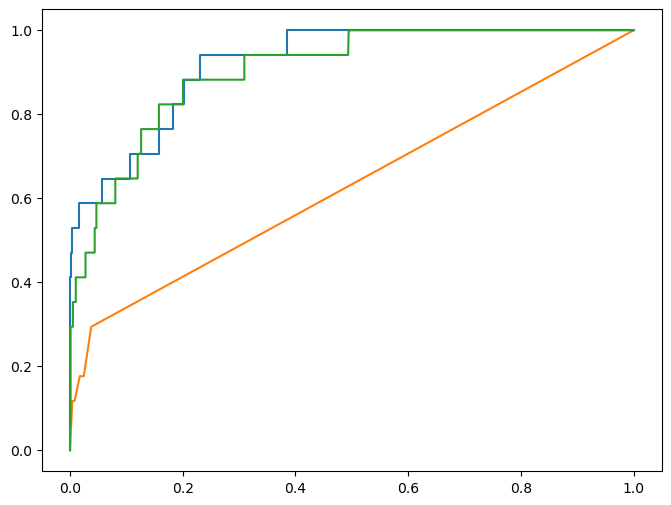

In [14]:


model_results = {}

plt.figure(figsize=(8, 6))

for name, model in models.items():

    print("\n")
    print("=" * 60)
    print("MODEL:", name)
    print("=" * 60)

    # Train model
    print("\nTraining model...")

    model.fit(
        X_train,
        y_train
    )

    # Predictions
    predictions = model.predict(
        X_test
    )

    probabilities = model.predict_proba(
        X_test
    )[:, 1]

    # Classification Report
    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            predictions,
            target_names=[
                "Legitimate",
                "Fraud"
            ]
        )
    )

    # Confusion Matrix
    print("Confusion Matrix:")

    cm = confusion_matrix(
        y_test,
        predictions
    )

    print(cm)

    # ROC-AUC
    auc = roc_auc_score(
        y_test,
        probabilities
    )

    print(
        f"\nROC-AUC Score: {auc:.4f}"
    )

    model_results[name] = auc

    # ROC Curve
    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )

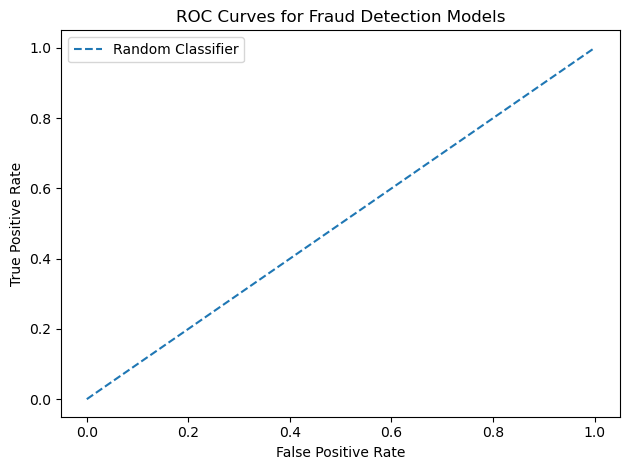

Saved: model_evaluation.png


In [15]:
# ============================================================
# ROC Curve
# ============================================================

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curves for Fraud Detection Models"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "model_evaluation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: model_evaluation.png")

In [16]:
# ============================================================
# Model Performance Comparison
# ============================================================

print("=" * 60)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 60)

for name, score in model_results.items():

    print(
        f"{name}: ROC-AUC = {score:.4f}"
    )

MODEL PERFORMANCE COMPARISON
Logistic Regression: ROC-AUC = 0.9210
Decision Tree: ROC-AUC = 0.6291
Random Forest: ROC-AUC = 0.9044


In [17]:
# ============================================================
# Best Model
# ============================================================

best_model = max(
    model_results,
    key=model_results.get
)

best_score = model_results[best_model]

print("Best Model:")
print(best_model)

print(
    f"\nBest ROC-AUC Score: {best_score:.4f}"
)

Best Model:
Logistic Regression

Best ROC-AUC Score: 0.9210


In [18]:
# ============================================================
# Project Completed
# ============================================================

print("=" * 60)
print("PROJECT COMPLETED SUCCESSFULLY!")
print("=" * 60)

print("\nGenerated Files:")
print("1. eda_overview.png")
print("2. model_evaluation.png")

PROJECT COMPLETED SUCCESSFULLY!

Generated Files:
1. eda_overview.png
2. model_evaluation.png
